Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from pathlib import Path
from tqdm import tqdm
import xarray as xr
import warnings
import seaborn as sns

warnings.filterwarnings("ignore")  # az.compare will throw warnings
plt.rcParams["figure.constrained_layout.use"] = True

# Individual level

In [2]:
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
participants_list = hrd_df.participant_id.unique()

In [ ]:
missing_participants = []
model_comparison_df = pd.DataFrame([])
session = 2
for participant_id in tqdm(participants_list):
    standard_path = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"standard_model_session{session}_{participant_id}.nc"
    )

    cardiac_believing_path = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"cardiac_believing_session{session}_{participant_id}.nc"
    )

    if (
        standard_path.exists()
        & cardiac_believing_path.exists()
    ):
        standard_idata = az.from_netcdf(standard_path)
        cardiac_believing_idata = az.from_netcdf(cardiac_believing_path)

        model_compare = az.compare(
            {
                "standard": standard_idata,
                "cardiac_beliefs": cardiac_believing_idata,
            },
            round_to="none",
        )
        model_compare["participant_id"] = participant_id
        model_compare["session"] = session
        model_comparison_df = pd.concat([model_comparison_df, model_compare])

    else:
        missing_participants.append((participant_id, session))


  0%|          | 0/549 [00:00<?, ?it/s]


  0%|          | 1/549 [00:00<01:47,  5.08it/s]


  1%|          | 3/549 [00:00<00:49, 10.95it/s]


  1%|          | 5/549 [00:00<00:53, 10.26it/s]


  1%|▏         | 7/549 [00:00<00:53, 10.08it/s]

...


 99%|█████████▊| 542/549 [00:52<00:00,  9.68it/s]


 99%|█████████▉| 544/549 [00:52<00:00,  9.92it/s]


 99%|█████████▉| 546/549 [00:52<00:00,  9.96it/s]


100%|█████████▉| 548/549 [00:53<00:00, 10.14it/s]


100%|██████████| 549/549 [00:53<00:00, 10.32it/s]

In [4]:
model_comparison_df["model"] = pd.Categorical(
    model_comparison_df.index,
    categories=["standard", "cardiac_beliefs"],
    ordered=True,
)
model_comparison_df = model_comparison_df.reset_index()

In [5]:
# arviz>=1 reports `elpd_diff` as a negative value (model - best), whereas older
# versions reported the positive magnitude (best - model). Take the absolute
# value so the figure and significance counts are independent of the convention.
model_comparison_df["elpd_diff_abs"] = model_comparison_df["elpd_diff"].abs()

mask_1 = (model_comparison_df["index"] == "standard") & (model_comparison_df["rank"] == 1)
diff_model_1 = model_comparison_df[mask_1].sort_values("elpd_diff_abs").elpd_diff_abs.to_numpy()
diff_se_model_1 = model_comparison_df[mask_1].sort_values("elpd_diff_abs").dse.to_numpy()

mask_2 = (model_comparison_df["index"] == "cardiac_beliefs") & (model_comparison_df["rank"] == 1)
diff_model_2 = model_comparison_df[mask_2].sort_values("elpd_diff_abs", ascending=False).elpd_diff_abs.to_numpy()
diff_se_model_2 = model_comparison_df[mask_2].sort_values("elpd_diff_abs", ascending=False).dse.to_numpy()

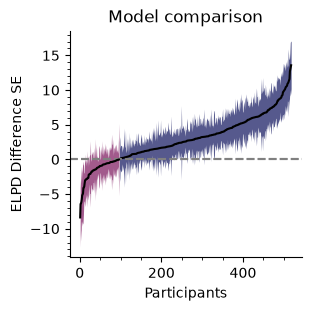

In [6]:
_, ax = plt.subplots(figsize=(3, 3))

x = np.arange(len(diff_model_1)) + len(diff_model_2) + 1
ax.fill_between(
    x=x, y1=diff_model_1-diff_se_model_1, y2=diff_model_1+diff_se_model_1, 
    color="#2c3071", linewidth=0, alpha=.8
)
ax.axhline(y=0, linestyle="--", color="gray")
ax.plot(x, diff_model_1, color="k")

x = np.arange(len(diff_model_2)) + 1
ax.fill_between(
    x=x, y1=-diff_model_2-diff_se_model_2, y2=-diff_model_2+diff_se_model_2, 
    color="#8b3170", linewidth=0, alpha=.8
)
ax.axhline(y=0, linestyle="--", color="gray")
ax.plot(x, -diff_model_2, color="k")

ax.set(xlabel="Participants", ylabel="ELPD Difference SE", title="Model comparison")

ax.minorticks_on()
sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_2_model_comparison.svg")

In [7]:
print(f"-> {diff_model_2.shape[0]} participants relying more on a model of dynamic beliefs ({sum(diff_model_2 - diff_se_model_2 > 0)} significant).")
print(f"-> {diff_model_1.shape[0]} participants relying more on a model of static beliefs ({sum(diff_model_1 - diff_se_model_1 > 0)} significant).")

-> 96 participants relying more on a model of dynamic beliefs (26 significant).
-> 422 participants relying more on a model of static beliefs (293 significant).
